In [66]:
import pandas as pd
import numpy as np
import json
import joblib
import shap
import matplotlib.pyplot as plt

In [67]:
# 1. Load the model directly
model_path = '../models/baselines/lightgbm_Sleep_Quality_Num.joblib'
lgbm_model = joblib.load(model_path)

/media/nata/7AAE88B3AE886989/Навчання/4 курс/Diploma/DS-Research-NS/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [68]:
# 2. Load the data
df = pd.read_csv('../data/processed/features_engineered_with_clusters.csv')

In [69]:
# Drop the targets so they don't leak into the features
targets = ['Sleep_Quality', 'Stress_Level', 'Health_Issues']
X_raw = df.drop(columns=targets, errors='ignore')

In [70]:
# 3. One-hot encode the categorical variables (like Country, Gender)
X_encoded = pd.get_dummies(X_raw)

In [71]:
# 4. The Magic Bullet: Align columns exactly to the model's expected 44 features
# If a column is missing from our sample, add it with 0s.
expected_features = lgbm_model.feature_name_
for col in expected_features:
    if col not in X_encoded.columns:
        X_encoded[col] = 0

In [72]:
# Reorder the columns to match the exact order the model expects
X_final = X_encoded[expected_features]

# Take a sample to keep SHAP calculations fast
X_sample = X_final.sample(n=1000, random_state=42)

In [73]:
# 5. Run SHAP 
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values computed successfully on {X_sample.shape[1]} features!")

SHAP values computed successfully on 44 features!


Generating detailed beeswarm plot...


<Figure size 1000x800 with 0 Axes>

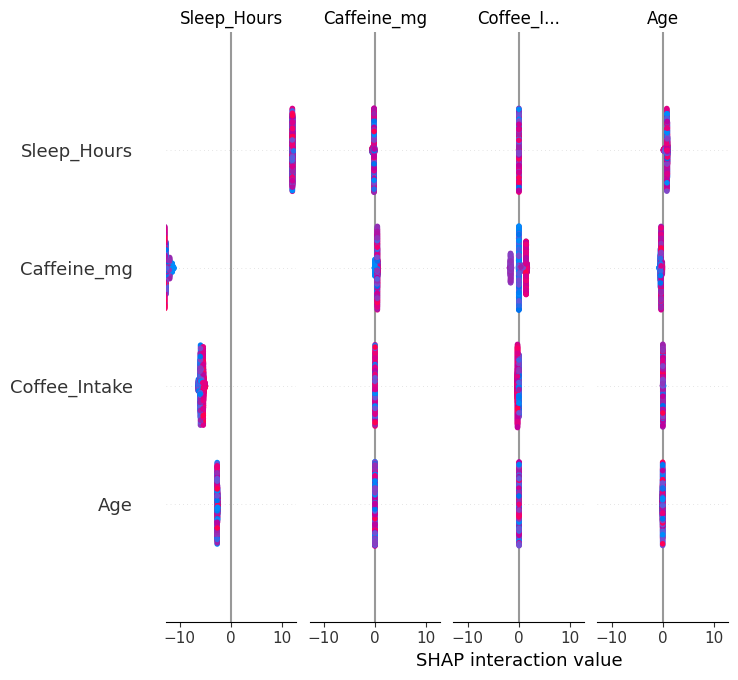

In [74]:
plt.figure(figsize=(10, 8))

# Check if the model is multi-class (returns a list of SHAP values)
if isinstance(shap_values, list):
    print("Multi-class model detected. Generating a global feature importance bar chart...")
    # For multi-class, a bar chart shows the average impact of features across all classes
    shap.summary_plot(shap_values, X_sample, plot_type="bar")
    
    print("\nGenerating a detailed beeswarm plot for Class 1...")
    # To see the detailed dot plot (beeswarm), we look at one specific class at a time
    shap.summary_plot(shap_values[1], X_sample)
else:
    print("Generating detailed beeswarm plot...")
    # For binary classification or regression, we just pass the values directly
    shap.summary_plot(shap_values, X_sample)

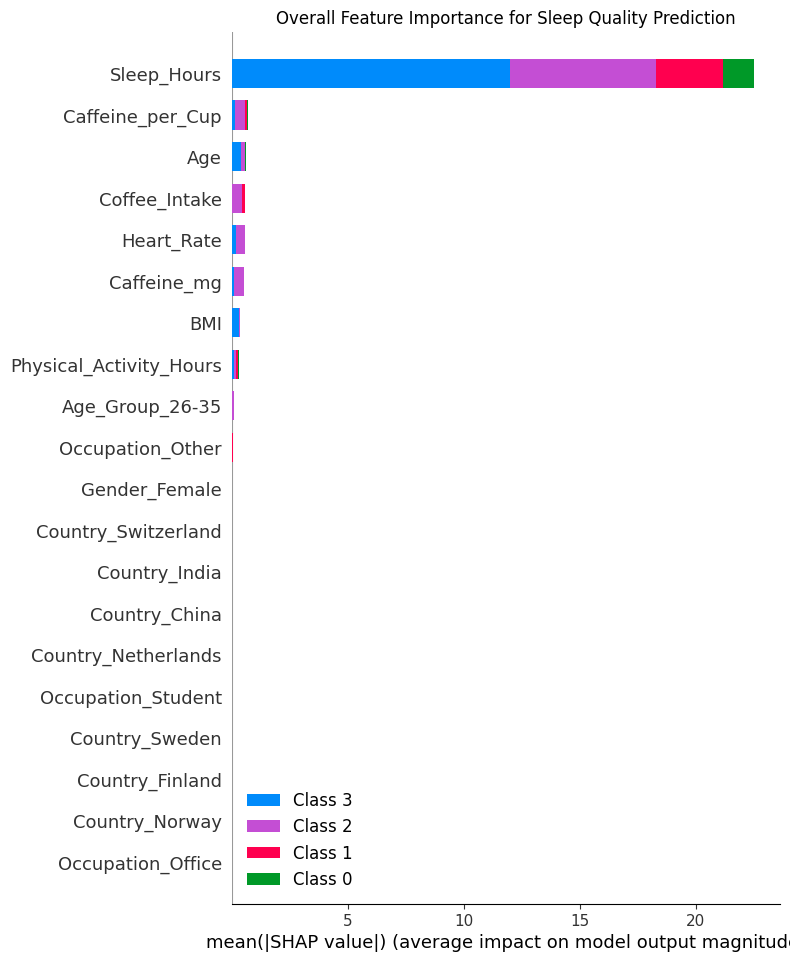

In [75]:
# Global importance bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Overall Feature Importance for Sleep Quality Prediction")
plt.show()

In [76]:
shap_explanation = explainer(X_sample)
user_index = 0

In [77]:
# 3. Cleanly extract the values based on the object's shape
if len(shap_explanation.values.shape) == 3:
    # If multiclass, it has 3 dimensions: (samples, features, classes)
    # We will explain Class 1
    user_shap_values = shap_explanation.values[user_index, :, 1]
    base_value = shap_explanation.base_values[user_index, 1]
else:
    # If regression/binary, it has 2 dimensions: (samples, features)
    user_shap_values = shap_explanation.values[user_index]
    base_value = shap_explanation.base_values[user_index]
    
# Extract the user's actual feature data
user_data = shap_explanation.data[user_index]

In [78]:
# 4. Build the data structure cleanly
feature_impacts = []
all_shap_sum = 0.0

for i, feature_name in enumerate(X_sample.columns):
    shap_val = float(user_shap_values[i])
    feat_val = float(user_data[i])
    
    all_shap_sum += shap_val
    
    # Ignore features with zero impact
    if abs(shap_val) < 0.001:
        continue
        
    feature_impacts.append({
        "feature": feature_name,
        "value": round(feat_val, 2),
        "shap_influence": round(shap_val, 4)
    })

In [79]:
# Sort by impact and grab the top 5
feature_impacts.sort(key=lambda x: abs(x["shap_influence"]), reverse=True)
top_features = feature_impacts[:5]

# Add the human-readable text
for item in top_features:
    influence = item["shap_influence"]
    item["impact"] = "positive" if influence > 0 else "negative"
    direction = "increased" if influence > 0 else "decreased"
    item["display_text"] = f"Your {item['feature']} value of {item['value']} {direction} your score."

In [80]:
# 5. Construct the final JSON payload
shap_json_payload = {
    "prediction_id": "poc-sample-123",
    "base_value": round(float(base_value), 4),
    "final_prediction": round(float(base_value + all_shap_sum), 4),
    "top_drivers": top_features
}

print(json.dumps(shap_json_payload, indent=4))

{
    "prediction_id": "poc-sample-123",
    "base_value": -6.2603,
    "final_prediction": -9.0672,
    "top_drivers": [
        {
            "feature": "Sleep_Hours",
            "value": 7.5,
            "shap_influence": -2.6048,
            "impact": "negative",
            "display_text": "Your Sleep_Hours value of 7.5 decreased your score."
        },
        {
            "feature": "Coffee_Intake",
            "value": 3.3,
            "shap_influence": -0.2448,
            "impact": "negative",
            "display_text": "Your Coffee_Intake value of 3.3 decreased your score."
        },
        {
            "feature": "Caffeine_per_Cup",
            "value": 95.15,
            "shap_influence": 0.1548,
            "impact": "positive",
            "display_text": "Your Caffeine_per_Cup value of 95.15 increased your score."
        },
        {
            "feature": "Country_Mexico",
            "value": 1.0,
            "shap_influence": -0.0754,
            "impact": "ne